100%|██████████| 18/18 [04:08<00:00, 13.78s/it]


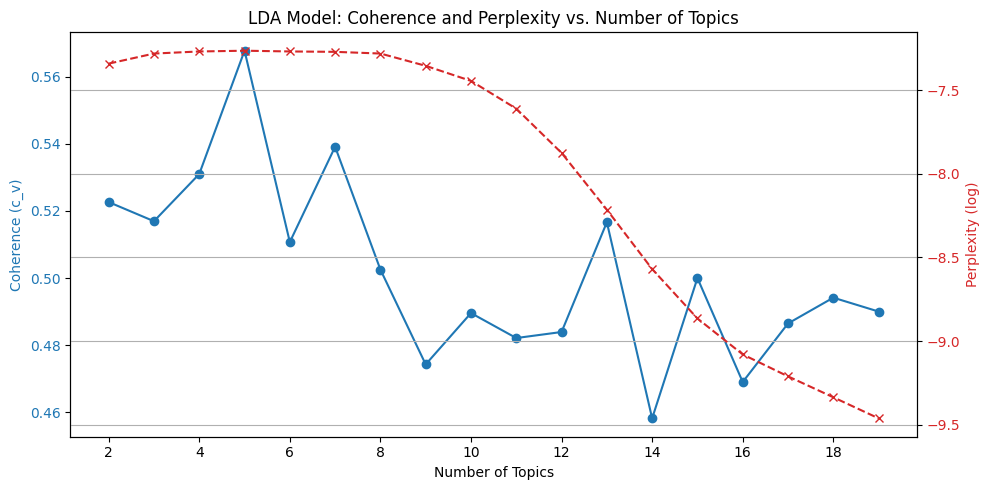

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
import re
import spacy
import json
import unicodedata
from gensim.models import Phrases
from gensim.models.phrases import Phraser

# =====================================================
# Configuration
# =====================================================
DATA_PATH = (
    r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Common\NTSB_ALL.csv"
)
GLOSSARY_PATH = (
    r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Common\Glossary.json"
)
# =====================================================
# NLTK setup
# =====================================================

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

STOPWORDS_LIST = set(stopwords.words("english"))

# =====================================================
# Load data
# =====================================================

NTSB_df = pd.read_csv(DATA_PATH)

# =====================================================
# Abbreviation expansion
# =====================================================

with open(GLOSSARY_PATH, "r", encoding="utf-8") as f:
    ABBREVIATIONS = json.load(f)


def expand_abbreviations(text, abbr_dict):
    if pd.isna(text):
        return text

    text = str(text)

    for abbr, full in abbr_dict.items():
        pattern = r"\b" + re.escape(abbr) + r"\b"
        text = re.sub(pattern, full, text, flags=re.IGNORECASE)

    return text


NTSB_df["narrative"] = (
    NTSB_df["narrative"]
    .astype(str)
    .apply(lambda x: expand_abbreviations(x, ABBREVIATIONS))
)

# =====================================================
# NLP preprocessing
# =====================================================
nlp_full = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def preprocess_text(text):

    if pd.isna(text):
        return []

    text = str(text)

    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text)

    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode()

    text = text.lower().strip()

    doc = nlp_full(text)

    tokens = [
        tok.lemma_
        for tok in doc
        if tok.lemma_
        and tok.lemma_ not in STOPWORDS_LIST
        and tok.is_alpha
        and len(tok.lemma_) >= 2
    ]

    return tokens


NTSB_df["tokens"] = NTSB_df["narrative"].apply(preprocess_text)
NTSB_df = NTSB_df[NTSB_df["tokens"].astype(bool)]


# =====================================================
# N-gram modeling
# =====================================================

bigram = Phrases(NTSB_df["tokens"], min_count=100, threshold=15)
trigram = Phrases(bigram[NTSB_df["tokens"]], min_count=75, threshold=20)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

NTSB_df["tokens_bigrams"] = NTSB_df["tokens"].apply(lambda x: bigram_mod[x])
NTSB_df["tokens_trigrams"] = (
    NTSB_df["tokens_bigrams"].apply(lambda x: trigram_mod[x])
)


STOPWORDS_AFTER = {
    "around", "back", "by", "first", "no", "not", "off", "on",
    "out", "over", "take", "top", "up", "aircraft", "airplane",
    "acft", "flight", "flt", "time", "fly"
}

NTSB_df["tokens_final"] = NTSB_df["tokens_trigrams"].apply(
    lambda toks: [t for t in toks if t not in STOPWORDS_AFTER]
)

# Create bigrams and trigrams
bigram = Phrases(NTSB_df['tokens'], min_count=60, threshold=15)
trigram = Phrases(bigram[NTSB_df['tokens']], min_count=55, threshold=20)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)
#fourgram_mod = Phraser(fourgram)

NTSB_df['tokens_bigrams'] = NTSB_df['tokens'].apply(lambda x: bigram_mod[x])
NTSB_df['tokens_trigrams'] = NTSB_df['tokens_bigrams'].apply(lambda x: trigram_mod[x])

# Define stopwords to remove AFTER bigram/trigram creation
stopwords_after_phrases = {
    "around", "back", "by", "first", "no", "not", "off", "on",
    "out", "over", "take", "top", "up", "aircraft", "airplane",
    "acft", "flight", "flt", "time", "fly"
}
NTSB_df["tokens_final"] = NTSB_df["tokens_trigrams"].apply(
    lambda toks: [t for t in toks if t not in STOPWORDS_AFTER]
)
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel
import gensim
import gensim.corpora as corpora
from tqdm import tqdm

# Prepare Dictionary and Corpus
id2word = corpora.Dictionary(NTSB_df['tokens_final'])

# Create corpus
texts = NTSB_df['tokens_final']
corpus = [id2word.doc2bow(text) for text in texts]

# Initialize lists to store results
coherence_values = []
perplexity_values = []
topic_nums = list(range(2, 20))

# Iterate over topic numbers
for num_topics in tqdm(topic_nums):
    # Train model on training set
    lda_model = gensim.models.ldamodel.LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=num_topics,
        random_state=100,
        update_every=1,
        chunksize=100,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # Compute coherence on validation texts
    coherence_model_lda = CoherenceModel(
        model=lda_model, 
        texts=texts, 
        dictionary=id2word, 
        coherence='c_v'
    )
    coherence = coherence_model_lda.get_coherence()
    
    # Compute perplexity on validation corpus
    perplexity = lda_model.log_perplexity(corpus)
    
    coherence_values.append(coherence)
    perplexity_values.append(perplexity)

# Plot results
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Topics')
ax1.set_xticks(range(2, 21, 2))
ax1.set_ylabel('Coherence (c_v)', color=color)
ax1.plot(topic_nums, coherence_values, marker='o', color=color, label='Coherence')
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Perplexity (log)', color=color)
ax2.plot(topic_nums, perplexity_values, marker='x', linestyle='--', color=color, label='Perplexity')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('LDA Model: Coherence and Perplexity vs. Number of Topics')
plt.grid(True)
plt.tight_layout()
plt.show()



Training LDA models: 100%|██████████| 18/18 [03:59<00:00, 13.30s/it]


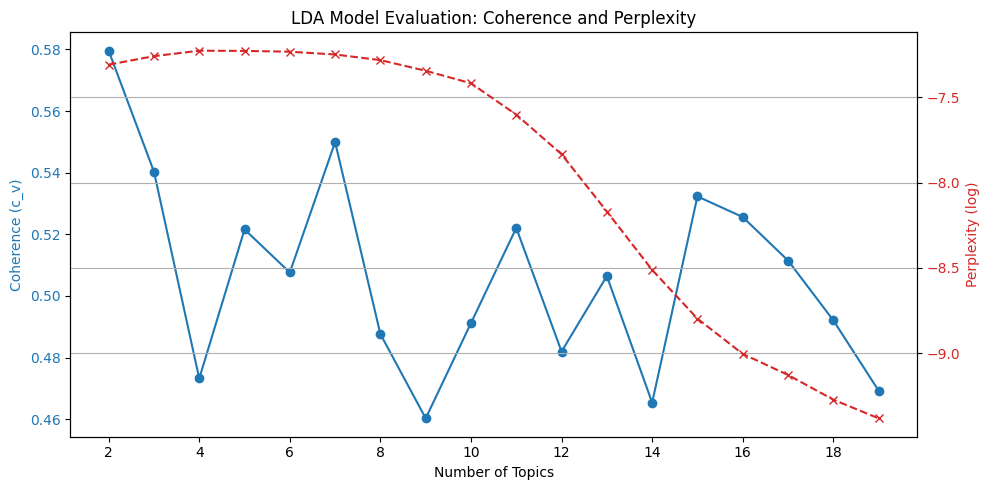

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
from tqdm import tqdm

# =====================================================
# Configuration
# =====================================================

DATA_PATH = r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Common\NTSB_ALL.csv"

RANDOM_STATE = 100
TOPIC_RANGE = range(2, 20)

# =====================================================
# Load and prepare data
# =====================================================

df = pd.read_csv(DATA_PATH)

df["tokens_final"] = (
    df["tokens_final_str"]
    .astype(str)
    .str.split()
)

texts = df["tokens_final"].tolist()

# =====================================================
# Create dictionary and corpus
# =====================================================

dictionary = corpora.Dictionary(texts)

corpus = [dictionary.doc2bow(text) for text in texts]

# =====================================================
# LDA evaluation across topic numbers
# =====================================================

coherence_scores = []
perplexity_scores = []

for num_topics in tqdm(TOPIC_RANGE, desc="Training LDA models"):

    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=RANDOM_STATE,
        chunksize=100,
        passes=10,
        update_every=1,
        alpha="auto",
        per_word_topics=True
    )

    # --- Coherence (semantic interpretability) ---
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )
    coherence_scores.append(coherence_model.get_coherence())

    # --- Perplexity (statistical fit) ---
    perplexity_scores.append(
        lda_model.log_perplexity(corpus)
    )


# =====================================================
# Plot coherence and perplexity
# =====================================================

fig, ax1 = plt.subplots(figsize=(10, 5))

# Coherence axis
ax1.set_xlabel("Number of Topics")
ax1.set_ylabel("Coherence (c_v)", color="tab:blue")
ax1.set_xticks(range(2, 21, 2))
ax1.plot(
    TOPIC_RANGE,
    coherence_scores,
    marker="o",
    color="tab:blue",
    label="Coherence"
)
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Perplexity axis
ax2 = ax1.twinx()
ax2.set_ylabel("Perplexity (log)", color="tab:red")
ax2.plot(
    TOPIC_RANGE,
    perplexity_scores,
    marker="x",
    linestyle="--",
    color="tab:red",
    label="Perplexity"
)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("LDA Model Evaluation: Coherence and Perplexity")
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
"""
lda_model_selection.py
--------------------------------------------------
Evaluates LDA models using coherence (c_v) and
perplexity across different numbers of topics.

Output:
- Saved plot: lda_coherence_perplexity.png
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
from tqdm import tqdm


# =====================================================
# Configuration
# =====================================================

DATA_PATH = r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Common\NTSB_ALL.csv"

OUTPUT_DIR = (
    r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB"
)

RANDOM_STATE = 100
TOPIC_RANGE = range(2, 20)

os.makedirs(OUTPUT_DIR, exist_ok=True)


# =====================================================
# Load and prepare data
# =====================================================

print("Loading data...")

df = pd.read_csv(DATA_PATH)

df["tokens_final"] = (
    df["tokens_final_str"]
    .astype(str)
    .str.split()
)

texts = df["tokens_final"].tolist()


# =====================================================
# Dictionary and corpus
# =====================================================

print("Creating dictionary and corpus...")

dictionary = corpora.Dictionary(texts)

corpus = [dictionary.doc2bow(text) for text in texts]


# =====================================================
# LDA evaluation
# =====================================================

coherence_scores = []
perplexity_scores = []

print("Training LDA models...")

for num_topics in tqdm(TOPIC_RANGE):

    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=RANDOM_STATE,
        chunksize=100,
        passes=10,
        update_every=1,
        alpha="auto",
        per_word_topics=True
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence_scores.append(coherence_model.get_coherence())
    perplexity_scores.append(lda_model.log_perplexity(corpus))


# =====================================================
# Plot results
# =====================================================

print("Saving evaluation plot...")

fig, ax1 = plt.subplots(figsize=(10, 5))

# Coherence axis
ax1.set_xlabel("Number of Topics")
ax1.set_ylabel("Coherence (c_v)", color="tab:blue")
ax1.set_xticks(range(2, 21, 2))
ax1.plot(
    list(TOPIC_RANGE),
    coherence_scores,
    marker="o",
    color="tab:blue"
)
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Perplexity axis
ax2 = ax1.twinx()
ax2.set_ylabel("Perplexity (log)", color="tab:red")
ax2.plot(
    list(TOPIC_RANGE),
    perplexity_scores,
    marker="x",
    linestyle="--",
    color="tab:red"
)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("LDA Model Evaluation: Coherence and Perplexity")
plt.grid(True)
plt.tight_layout()

plot_path = os.path.join(
    OUTPUT_DIR,
    "lda_coherence_perplexity.png"
)

plt.savefig(plot_path, bbox_inches="tight")
plt.close()

print(f"Plot saved → {plot_path}")
print("LDA model selection completed successfully.")


Loading data...
Creating dictionary and corpus...
Training LDA models...


100%|██████████| 18/18 [04:47<00:00, 15.95s/it]

Saving evaluation plot...
Plot saved → C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\lda_coherence_perplexity.png
LDA model selection completed successfully.


In [4]:
from gensim.models import CoherenceModel
import gensim
import gensim.corpora as corpora
from tqdm import tqdm
import os


# Function to compute metrics
def compute_coherence_perplexity(corpus, dictionary, k, a):
    lda_model = gensim.models.ldamodel.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k, 
        update_every=1,
        random_state=100,
        chunksize=100,
        passes=10,
        alpha=a
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )
    return coherence_model.get_coherence(), lda_model.log_perplexity(corpus)

# Parameter grid
topics_range = [5,6,7,8,9,13,15]

alpha = [0.01,0.1,0.3,0.5,0.7,0.9,1.1]
alpha += ['symmetric', 'asymmetric']

model_results = {
    'Topics': [],
    'Alpha': [],
    'Coherence': [],
    'Perplexity': []
}

# Grid Search for LDA

pbar = tqdm(total=len(alpha)*len(topics_range))

for k in topics_range:
    for a in alpha:
            cv, per = compute_coherence_perplexity(
                corpus=corpus, 
                dictionary=dictionary, 
                k=k, a=a
            )
            model_results['Topics'].append(k)
            model_results['Alpha'].append(a)
            model_results['Coherence'].append(cv)
            model_results['Perplexity'].append(per)
            pbar.update(1)

pbar.close()

# Save results
os.makedirs("./results", exist_ok=True)
pd.DataFrame(model_results).to_csv(r'C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\lda_grid_search.csv', index=False)

  0%|          | 0/63 [00:46<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
"""
lda_grid_search.py
--------------------------------------------------
Grid search for LDA hyperparameters using:

- Number of topics (k)
- Alpha values

Evaluation metrics:
- Coherence (c_v)
- Perplexity

Results are saved to CSV for later analysis.
"""

import os
import pandas as pd
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
from tqdm import tqdm
import matplotlib.pyplot as plt


# =====================================================
# Configuration
# =====================================================

RANDOM_STATE = 100
PASSES = 10
CHUNKSIZE = 100

TOPIC_RANGE = [5, 7, 10, 11, 13, 15]
ALPHA_VALUES = [
    0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1,
    "symmetric", "asymmetric"
]

DATA_PATH = (
    r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Common\NTSB_ALL.csv"
)

OUTPUT_PATH = (
    r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes"
    r"\Approach_1\NTSB\lda_grid_search.csv"
)
PLOT_PATH = (
    r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes"
    r"\Approach_1\NTSB\lda_grid_search_coherence_plot.png"
)



# =====================================================
# Load and prepare data
# =====================================================

print("Loading data...")

df = pd.read_csv(DATA_PATH)

df["tokens_final"] = (
    df["tokens_final_str"]
    .astype(str)
    .str.split()
)

texts = df["tokens_final"].tolist()


# =====================================================
# Dictionary and corpus
# =====================================================

print("Creating dictionary and corpus...")

dictionary = corpora.Dictionary(texts)

corpus = [dictionary.doc2bow(text) for text in texts]



# =====================================================
# LDA evaluation function
# =====================================================

def evaluate_lda_model(
    corpus,
    dictionary,
    texts,
    num_topics,
    alpha
):
    """
    Trains an LDA model and returns coherence and perplexity.
    """

    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        alpha=alpha,
        random_state=RANDOM_STATE,
        update_every=1,
        chunksize=CHUNKSIZE,
        passes=PASSES
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = coherence_model.get_coherence()
    perplexity = lda_model.log_perplexity(corpus)

    return coherence, perplexity


# =====================================================
# Grid search
# =====================================================

results = {
    "num_topics": [],
    "alpha": [],
    "coherence_cv": [],
    "perplexity": []
}

total_runs = len(TOPIC_RANGE) * len(ALPHA_VALUES)

with tqdm(total=total_runs, desc="LDA grid search") as pbar:

    for k in TOPIC_RANGE:
        for a in ALPHA_VALUES:

            coherence, perplexity = evaluate_lda_model(
                corpus=corpus,
                dictionary=dictionary,
                texts=texts,
                num_topics=k,
                alpha=a
            )

            results["num_topics"].append(k)
            results["alpha"].append(a)
            results["coherence_cv"].append(coherence)
            results["perplexity"].append(perplexity)

            pbar.update(1)


df = pd.DataFrame(results)


Loading data...
Creating dictionary and corpus...


LDA grid search: 100%|██████████| 54/54 [13:15<00:00, 14.72s/it]


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\55279\\Desktop\\Mestrado\\0.Thesis\\Codes\\Approach_1\\NTSB\\lda_grid_search.csv'

In [57]:
df.to_csv(r'C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\lda_grid_search.csv', index=False)
# =====================================================
# Plot coherence results - FIXED VERSION
# =====================================================

plt.figure(figsize=(16, 8))

# Create a list of all alpha values as strings for consistent mapping
alpha_labels = [str(a) for a in ALPHA_VALUES]

for t in sorted(df["num_topics"].unique()):
    subset = df[df["num_topics"] == t].copy()
    
    # Ensure all alpha values are strings for consistent comparison
    subset["alpha_str"] = subset["alpha"].astype(str)
    
    # Create a proper ordering
    subset["order"] = subset["alpha_str"].apply(lambda x: alpha_labels.index(x) if x in alpha_labels else len(alpha_labels))
    subset = subset.sort_values("order")
    
    # Get the numeric positions for plotting
    x_positions = [alpha_labels.index(a) for a in subset["alpha_str"]]
    
    plt.plot(
        x_positions,
        subset["coherence_cv"],
        marker="o",
        label=f"{t} topics"
    )

# Set x-ticks with original alpha labels
plt.xticks(
    ticks=range(len(alpha_labels)),
    labels=alpha_labels,
    rotation=45
)

plt.xlabel("Alpha")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence vs Alpha (grouped by number of topics)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# SAVE
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight')
plt.close()

print(f"Coherence plot saved → {PLOT_PATH}")

Coherence plot saved → C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\lda_grid_search_coherence_plot.png


In [73]:

# Build LDA optimized model 
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                            id2word=dictionary,
                                            num_topics=11, 
                                            random_state=100,
                                            update_every=1,
                                            chunksize=100,
                                            passes=10,
                                            alpha=1.1)

topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)
coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
print(coherence_model_lda.get_coherence())  

(0, '0.030*"door" + 0.018*"crew" + 0.018*"emergency" + 0.014*"system" + 0.013*"fire"')
(1, '0.059*"runway" + 0.021*"taxiway" + 0.016*"pilot" + 0.014*"foot" + 0.014*"controller"')
(2, '0.038*"passenger" + 0.038*"airbus" + 0.028*"international_airport" + 0.025*"provision" + 0.024*"operate"')
(3, '0.087*"control" + 0.039*"california" + 0.034*"aileron" + 0.027*"pacific" + 0.025*"stabilizer"')
(4, '0.019*"degree" + 0.013*"knot" + 0.012*"pilot" + 0.012*"foot" + 0.009*"instrument"')
(5, '0.046*"attendant" + 0.029*"turbulence" + 0.024*"encounter" + 0.019*"passenger" + 0.017*"captain"')
(6, '0.027*"wheel" + 0.018*"nose" + 0.016*"maintenance" + 0.015*"examination" + 0.015*"main_landing_gear"')
(7, '0.067*"report" + 0.063*"accident" + 0.044*"alaska" + 0.028*"anchorage" + 0.027*"cargo"')
(8, '0.062*"passenger" + 0.035*"instrument" + 0.027*"rule" + 0.026*"operate" + 0.021*"international_airport"')
(9, '0.020*"gate" + 0.020*"tug" + 0.017*"ground" + 0.015*"right" + 0.014*"wing"')
(10, '0.048*"engine"

In [78]:
"""final_model.py"""
import os
from gensim.models import LdaModel, CoherenceModel
import gensim.corpora as corpora
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis


# =========================
# CONFIG
# =========================
DATA_PATH = (
    r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Common\NTSB_ALL.csv"
)
OUTPUT_DIR = r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB"
NUM_TOPICS = 11
RANDOM_STATE = 100

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================
# Load and prepare data
# =====================================================

print("Loading data...")

df = pd.read_csv(DATA_PATH)

df["tokens_final"] = (
    df["tokens_final_str"]
    .astype(str)
    .str.split()
)

texts = df["tokens_final"].tolist()


# =====================================================
# Dictionary and corpus
# =====================================================

print("Creating dictionary and corpus...")

dictionary = corpora.Dictionary(texts)

corpus = [dictionary.doc2bow(text) for text in texts]


# =========================
# 1. Train LDA model
# =========================

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=RANDOM_STATE,
    chunksize=100,
    passes=1,
    alpha=1.3,
    update_every=1
)


# =========================
# 2. Coherence
# =========================

coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

coherence_score = coherence_model.get_coherence()

with open(f"{OUTPUT_DIR}/coherence.txt", "w") as f:
    f.write(f"Coherence score: {coherence_score:.4f}")


# =========================
# 3. Topics + keywords
# =========================

topics_data = []

for topic_id in range(NUM_TOPICS):
    words = lda_model.show_topic(topic_id, topn=10)
    topics_data.append({
        "topic_id": topic_id,
        "keywords": ", ".join([w for w, _ in words])
    })

df_topics_words = pd.DataFrame(topics_data)
df_topics_words.to_csv(f"{OUTPUT_DIR}/topics_keywords.csv", index=False)


# =========================
# 4. Representative documents
# =========================

topic_docs = {i: [] for i in range(NUM_TOPICS)}

for doc_id, bow in enumerate(corpus):
    for topic_id, prob in lda_model.get_document_topics(bow):
        topic_docs[topic_id].append((doc_id, prob))

rep_docs = []

for topic_id, docs in topic_docs.items():
    best_doc_id = max(docs, key=lambda x: x[1])[0]
    rep_docs.append({
        "topic_id": topic_id,
        "document": " ".join(texts[best_doc_id])  
    })

df_rep_docs = pd.DataFrame(rep_docs)
df_rep_docs.to_csv(f"{OUTPUT_DIR}/representative_documents.csv", index=False)


# =========================
# 5. PyLDAvis
# =========================

lda_vis = gensimvis.prepare(
    lda_model,
    corpus,
    dictionary,
    mds="mmds"
)

pyLDAvis.save_html(
    lda_vis,
    f"{OUTPUT_DIR}/lda_visualization.html"
)


# =========================
# 6. Topic distributions
# =========================

topic_distributions = [
    [prob for _, prob in sorted(
        lda_model.get_document_topics(bow, minimum_probability=0),
        key=lambda x: x[0]
    )]
    for bow in corpus
]

df_topic_dist = pd.DataFrame(
    topic_distributions,
    columns=[f"Topic_{i}" for i in range(NUM_TOPICS)]
)

df_topic_dist.to_csv(
    f"{OUTPUT_DIR}/document_topic_distributions.csv",
    index=False
)


# =========================
# 7. Topic correlation heatmap
# =========================

corr_matrix = df_topic_dist.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True)
plt.title("Topic Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/topic_correlation_heatmap.png", dpi=300)
plt.close()


Loading data...
Creating dictionary and corpus...


c:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\gensim\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


In [85]:
import pandas as pd
import numpy as np

# Load document-topic distributions
file_path = r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\document_topic_distributions.csv"
df = pd.read_csv(file_path)

# Adaptive threshold per document: mean + 0.5 * std
alpha = 0.5
thresholds = df.mean(axis=1) + alpha * df.std(axis=1)

# Convert to binary: topic is present if greater than its document's threshold
binary_matrix = df.gt(thresholds, axis=0).astype(int)

# Save the binary matrix
binary_matrix.to_csv(r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\binary_document_topics_adaptive.csv")

print("Binary matrix saved. Example:")
print(binary_matrix.head())


Binary matrix saved. Example:
   Topic_0  Topic_1  Topic_2  Topic_3  Topic_4  Topic_5  Topic_6  Topic_7  \
0        1        0        0        0        1        0        1        0   
1        0        0        0        0        1        0        1        0   
2        0        0        0        0        0        1        0        0   
3        0        0        0        0        0        0        0        0   
4        0        0        0        0        0        1        0        0   

   Topic_8  Topic_9  Topic_10  
0        0        0         0  
1        0        0         0  
2        0        0         0  
3        0        0         1  
4        1        0         0  


In [86]:
"""
10_causal_discovery_fci_bootstrap.py

"""

from __future__ import annotations
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# Configuration
# =============================================================================

# Input produced by Program 08
INPUT_CSV = Path(
    r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\binary_document_topics_adaptive.csv")

# Output directory
OUT_DIR = Path(r"C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\causal_output")

# Conservative rule of thumb for constraint-based methods
MIN_SAMPLES_PER_FEATURE = 5

# Significance level for conditional independence tests
ALPHA = 0.05

# Visualization settings
GRAPH_DPI = 300  # High resolution for publications
GRAPH_FIGSIZE = (12, 8)  # Figure size in inches
NODE_SIZE = 2000  # Size of nodes in the graph
FONT_SIZE = 7  # Font size for node labels


# =============================================================================
# Utility functions
# =============================================================================

def sufficient_sample_size(n_samples: int, n_features: int) -> bool:
    """
    Check whether sample size is sufficient for FCI / PC style algorithms.

    This is intentionally conservative.
    """
    return n_samples >= MIN_SAMPLES_PER_FEATURE * n_features


def ensure_output_dir() -> None:
    """Create output directory if it does not already exist."""
    OUT_DIR.mkdir(parents=True, exist_ok=True)


def encode_and_clean_binary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Defensive cleaning for a binary feature matrix.

    Steps:
    1) Convert boolean columns to {0,1}
    2) Drop rows with missing values (strict, avoids CI-test issues)
    3) Attempt to cast all features to integer
    """
    df2 = df.copy()

    # Convert booleans to integers
    for col in df2.columns:
        if df2[col].dtype == bool:
            df2[col] = df2[col].astype(int)

    # Drop rows with any missing values
    n_before = len(df2)
    df2 = df2.dropna(axis=0)
    n_after = len(df2)

    if n_after < n_before:
        print(
            f"[WARN] Dropped {n_before - n_after} rows due to missing values.")

    # Attempt to cast to int
    try:
        df2 = df2.astype(int)
    except Exception:
        print("[WARN] Couldn't cast all columns to int")

    return df2


def drop_constant_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop constant (degenerate) columns."""
    keep_cols = []
    dropped_cols = []

    for col in df.columns:
        if df[col].nunique(dropna=True) <= 1:
            dropped_cols.append(col)
        else:
            keep_cols.append(col)

    if dropped_cols:
        print(f"[WARN] Dropping constant features: {dropped_cols}")

    return df[keep_cols]


def extract_edges_from_pag(cg, var_names: List[str]) -> pd.DataFrame:
    """
    Convert a causal-learn PAG object into a flat edge list.

    Each edge is represented as:
        source | target | endpoints
    """
    edges: List[Tuple[str, str, str]] = []

    # Handle GeneralGraph object directly
    if hasattr(cg, 'graph'):
        G = cg.graph
    elif hasattr(cg, 'G') and hasattr(cg.G, 'graph'):
        G = cg.G.graph
    else:
        G = cg

    # Get dimensions
    if hasattr(G, 'shape'):
        p = G.shape[0]
    else:
        print(f"[ERROR] Can't determine graph dim from type {type(G)}")
        return pd.DataFrame(edges, columns=["source", "target", "endpoints"])

    # Extract edges from adjacency matrix
    for i in range(p):
        for j in range(i + 1, p):
            # Check if there's any connection between i and j
            if hasattr(G[i, j], 'name') and hasattr(G[j, i], 'name'):
                ei_name = getattr(G[i, j], 'name', str(G[i, j]))
                ej_name = getattr(G[j, i], 'name', str(G[j, i]))
                if ei_name != "NO_EDGE" or ej_name != "NO_EDGE":
                    edges.append((var_names[i], var_names[j], f"{ei_name}--{ej_name}"))
            else:
                ei_val = G[i, j]
                ej_val = G[j, i]
                if ei_val != 0 or ej_val != 0:
                    edges.append((var_names[i], var_names[j], f"{ei_val}--{ej_val}"))

    return pd.DataFrame(edges, columns=["source", "target", "endpoints"])


def visualize_causal_graph(edges_df: pd.DataFrame, var_names: List[str],
                           output_path: Path) -> None:
    """
    Generate a publication-quality visualization of the causal graph.

    Args:
        edges_df: DataFrame containing edges with endpoints
        var_names: List of all variable names
        output_path: Path to save the visualization
    """
    if edges_df.empty:
        print("[VISUALIZATION] No edges to visualize.")
        return

    try:
        import networkx as nx
        print("[VISUALIZATION] Generating causal graph visualization...")

        # Create directed graph with NetworkX
        G = nx.DiGraph()

        # Add nodes
        for var in var_names:
            G.add_node(var)

        # Process edges and add them to graph
        edge_types = []
        for _, row in edges_df.iterrows():
            source, target, endpoints = row['source'], row['target'], row['endpoints']

            # Parse endpoint types
            if '--' in endpoints:
                left_end, right_end = endpoints.split('--')

                # Determine edge type based on endpoints
                if '1' in right_end and '-1' in left_end:
                    # Directed edge (causal)
                    G.add_edge(source, target, style='solid', color='red',
                               arrowstyle='->')
                    edge_types.append('directed')
                elif '1' in left_end and '-1' in right_end:
                    # Reverse directed edge
                    G.add_edge(target, source, style='solid', color='red',
                               arrowstyle='->')
                    edge_types.append('reverse_directed')
                elif '1' in left_end and '1' in right_end:
                    # Bidirectional edge (unoriented confounding)
                    G.add_edge(source, target, style='solid', color='purple',
                               arrowstyle='<->')
                    G.add_edge(target, source, style='solid', color='purple')
                    edge_types.append('bidirectional')
                elif '1' in right_end and '2' in left_end:
                    # Partially directed edge (possible causation)
                    G.add_edge(source, target, style='solid', color='blue',
                               arrowstyle='->')
                    edge_types.append('partially_directed')
                elif '1' in left_end and '2' in right_end:
                    # Reverse partially directed edge
                    G.add_edge(target, source, style='solid', color='blue',
                               arrowstyle='->')
                    edge_types.append('reverse_partial')
                elif '2' in left_end and '2' in right_end:
                    # Non-directed edge (unoriented)
                    G.add_edge(source, target, style='dotted', color='gray',
                               arrowstyle='-')
                    G.add_edge(target, source, style='dotted', color='gray')
                    edge_types.append('non_directed')
            else:
                # Default to simple directed edge
                G.add_edge(source, target, style='solid', color='black')
                edge_types.append('default')

        # Create figure with better aesthetics
        plt.figure(figsize=GRAPH_FIGSIZE, dpi=GRAPH_DPI)

        # Use spring layout for better node positioning
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

        # Draw nodes
        nx.draw_networkx_nodes(
            G, pos,
            node_color='lightblue',
            node_size=NODE_SIZE,
            alpha=0.5,
            linewidths=1.5
        )

        # Draw labels
        nx.draw_networkx_labels(
            G, pos,
            font_size=FONT_SIZE,
            font_weight='bold',
            font_family='Arial'
        )

        # Draw edges with different styles based on type
        edge_colors = [G[u][v].get('color') for u, v in G.edges()]
        edge_styles = [G[u][v].get('style') for u, v in G.edges()]
        edge_widths = [2.0 if G[u][v].get('color') == 'red' else 1.5 for u, v in G.edges()]

        nx.draw_networkx_edges(
            G, pos,
            edge_color=edge_colors,
            style=edge_styles,
            width=edge_widths,
            arrows=True,
            arrowstyle='-|>',
            arrowsize=15
        )

        # Add title and legend
        plt.title('Causal Graph (PAG) from FCI Algorithm', fontsize=14,
                  fontweight='bold', pad=20)

        # Create custom legend for edge types
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='lightblue', edgecolor='darkblue',
                  label='Variable Node'),
            Patch(facecolor='none', edgecolor='red',
                  label='Directed Edge (Causal)'),
            Patch(facecolor='none', edgecolor='blue',
                  label='Partially Directed Edge'),
            Patch(facecolor='none', edgecolor='purple',
                  label='Bidirected Edge (Confounding)'),
            Patch(facecolor='none', edgecolor='gray',
                  label='Non-directed Edge'),
        ]

        plt.legend(
            handles=legend_elements,
            loc='upper right',
            frameon=True,
            framealpha=0.9,
            fontsize=9
        )

        # Add statistics text box
        stats_text = f"""
        Graph Statistics:
        • Variables: {len(var_names)}
        • Edges: {len(edges_df)}
        • Directed edges: {edge_types.count('directed') + edge_types.count('reverse_directed')}
        • Partially directed: {edge_types.count('partially_directed') + edge_types.count('reverse_partial')}
        • Bidirected: {edge_types.count('bidirectional')}
        """

        plt.text(
            0.02, 0.02, stats_text,
            transform=plt.gca().transAxes,
            fontsize=8,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        )

        # Remove axes and set tight layout
        plt.axis('off')
        plt.tight_layout()

        # Save figure
        plt.savefig(output_path, dpi=GRAPH_DPI, bbox_inches='tight',
                    facecolor='white')
        plt.close()

        print(f"[VISUALIZATION] Graph saved → {output_path}")

    except ImportError:
        print("[WARN] NetworkX not available")
        print("[INFO] Skipping graph visualization.")
    except Exception as e:
        print(f"[WARN] Failed to create visualization: {e}")
        print("[INFO] Continuing without graph visualization.")


# =============================================================================
# Main logic
# =============================================================================

def main():
    # Guard 0: input exists
    if not INPUT_CSV.exists():
        print(f"[ERROR] Input file not found: {INPUT_CSV}")
        return

    # Load accident-level features
    df = pd.read_csv(INPUT_CSV, index_col=0)
    print(f"[INFO] Loaded feature matrix: {INPUT_CSV}")
    print(f"[INFO] Original shape: {df.shape} (samples, features)")

    # Defensive preprocessing
    df = encode_and_clean_binary(df)
    df = drop_constant_columns(df)
    n_samples, n_features = df.shape
    print(f"[INFO] After cleaning: {n_samples} samples, {n_features} features")

    # Guard 1: sample size sufficiency
    if not sufficient_sample_size(n_samples, n_features):
        print(
            "\n[SKIP] Insufficient samples for causal discovery.\n"
            f"       Required ≥ {MIN_SAMPLES_PER_FEATURE} × {n_features} = "
            f"{MIN_SAMPLES_PER_FEATURE * n_features}\n"
            f"       Found    = {n_samples}\n"
            "       Program 09 exits safely."
        )
        return

    print("[OK] Sample size sufficient. Running FCI...")
    print("[INFO] CI test: discrete G-squared (CIT('gsq'))")
    print(f"[INFO] Alpha  : {ALPHA}")

    # Prepare data for causal-learn
    data = df.values.astype(float)
    # just extract the word between [""] in the column names
    var_names: List[str] = list(df.columns)

    # Run FCI (causal-learn 0.1.4.3)
    from causallearn.search.ConstraintBased.FCI import fci
    from causallearn.utils.cit import CIT

    # Primary CI test for discrete/binary data
    try:
        cit = CIT(data, "gsq")
    except ValueError:
        print("[WARN] CIT method 'gsq' unavailable; falling back to 'chisq'.")
        cit = CIT(data, "chisq")

    # Handle fci() return value
    fci_result = fci(
        data,
        independence_test=cit,
        alpha=ALPHA,
        verbose=True,
        variable_names=var_names,
    )

    # Extract graph from result
    if isinstance(fci_result, tuple):
        cg = fci_result[0]
        print(f"[INFO] fci() returned tuple of length {len(fci_result)}")
    else:
        cg = fci_result

    ensure_output_dir()

    # Save PAG (text form)
    pag_path = OUT_DIR / "causal_pag.txt"
    with open(pag_path, "w", encoding="utf-8") as f:
        f.write(str(cg))
    print(f"[OK] PAG written → {pag_path}")

    # Save edge list
    edges_df = extract_edges_from_pag(cg, var_names)
    edges_path = OUT_DIR / "causal_edges.csv"
    edges_df.to_csv(edges_path, index=False, encoding="utf-8-sig")
    print(f"[OK] Edge list written → {edges_path}")
    print(f"[INFO] Number of edges: {len(edges_df)}")

    # Generate visualization
    graph_path = OUT_DIR / "causal_graph.png"
    visualize_causal_graph(edges_df, var_names, graph_path)

    # Print summary
    print("\n" + "=" * 60)
    print("CAUSAL DISCOVERY SUMMARY")
    print("=" * 60)
    print(f"Dataset: {n_samples} samples × {n_features} features")
    print(f"Significance level (alpha): {ALPHA}")
    print(f"Discovered edges: {len(edges_df)}")

    if len(edges_df) > 0:
        print("\nTop 5 causal relationships (by alphabetical order):")
        for i, (_, row) in enumerate(edges_df.head(5).iterrows()):
            print(f"{i+1}. {row['source']} → {row['target']} ({row['endpoints']})")

    print(f"\nOutput files saved to: {OUT_DIR}")
    print("  1. causal_pag.txt     - Text representation of PAG")
    print("  2. causal_edges.csv   - Edge list with endpoints")
    print("  3. causal_graph.png   - Publication-quality visualization")
    print("=" * 60)
    print("\n[DONE] Program 10 completed successfully")


# =============================================================================
# Entry point
# =============================================================================

if __name__ == "__main__":
    main()



[INFO] Loaded feature matrix: C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\binary_document_topics_adaptive.csv
[INFO] Original shape: (845, 11) (samples, features)
[INFO] After cleaning: 845 samples, 11 features
[OK] Sample size sufficient. Running FCI...
[INFO] CI test: discrete G-squared (CIT('gsq'))
[INFO] Alpha  : 0.05


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 328.21it/s]

0 dep 1 | () with p-value 0.004664

0 ind 2 | () with p-value 0.399652

0 ind 3 | () with p-value 0.163279

0 ind 4 | () with p-value 0.355915

0 dep 5 | () with p-value 0.000001

0 dep 6 | () with p-value 0.048059

0 ind 7 | () with p-value 0.106532

0 ind 8 | () with p-value 0.081733

0 ind 9 | () with p-value 0.284992

0 ind 10 | () with p-value 0.343591

1 dep 0 | () with p-value 0.004664

1 ind 2 | () with p-value 0.307576

1 ind 3 | () with p-value 0.275192

1 ind 4 | () with p-value 0.053254

1 dep 5 | () with p-value 0.000006

1 dep 6 | () with p-value 0.010866

1 ind 7 | () with p-value 0.059022

1 ind 8 | () with p-value 0.057359

1 ind 9 | () with p-value 0.434008

1 dep 10 | () with p-value 0.044170

2 ind 0 | () with p-value 0.399652

2 ind 1 | () with p-value 0.307576

2 dep 3 | () with p-value 0.000000

2 dep 4 | () with p-value 0.041916

2 dep 5 | () with p-value 0.018088

2 ind 6 | () with p-value 0.162223

2 dep 7 | () with p-value 0.000000

2 ind 8 | () with p-value 

[VISUALIZATION] Graph saved → C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\causal_output\causal_graph.png

CAUSAL DISCOVERY SUMMARY
Dataset: 845 samples × 11 features
Significance level (alpha): 0.05
Discovered edges: 15

Top 5 causal relationships (by alphabetical order):
1. Topic_0 → Topic_1 (2--2)
2. Topic_0 → Topic_5 (2--1)
3. Topic_1 → Topic_5 (2--1)
4. Topic_1 → Topic_6 (2--2)
5. Topic_2 → Topic_3 (1--2)

Output files saved to: C:\Users\55279\Desktop\Mestrado\0.Thesis\Codes\Approach_1\NTSB\causal_output
  1. causal_pag.txt     - Text representation of PAG
  2. causal_edges.csv   - Edge list with endpoints
  3. causal_graph.png   - Publication-quality visualization

[DONE] Program 10 completed successfully


In [76]:
import numpy as np
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.GraphUtils import GraphUtils

# =====================================================
# Configuration
# =====================================================
DATA_PATH 

built document topic matrix 

# --- Prepare data for FCI ---
X = df_topics.to_numpy()

topic_labels = []
for i in range(lda_model.num_topics):
    words = [word for word, prob in lda_model.show_topic(i, topn=1)]  # top 2 words
    label = "_".join(words)
    topic_labels.append(label)

node_names = topic_labels

# Step 2: Limit conditioning depth (optional)
g, edges = fci(X, node_names=node_names, independence_test_method="fisherz", depth=2)
# --- Visualization ---
pdy = GraphUtils.to_pydot(g)
pdy.write_png('fci_lda_ntsb1.png')

print("FCI completed and graph saved as 'fci_result_7topics.png'.")

SyntaxError: invalid syntax (2112352577.py, line 10)

In [14]:
# --- Binarize df_topics ---
df_binary = (df_topics > 0.8).astype(int)

# --- Prepare data for FCI ---
X = df_binary.to_numpy()

# Step 2: Limit conditioning depth (optional)
g, edges = fci( X, node_names=node_names, independence_test_method="fisherz", depth=2)
# --- Visualization ---
pdy = GraphUtils.to_pydot(g)
pdy.write_png('fci_lda_ntsb2.png')

print("FCI completed and graph saved as 'fci_result_7topics.png'.")

c:\Users\55279\Desktop\Mestrado\0.Thesis\dados\Code\gensim\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\55279\Desktop\Mestrado\0.Thesis\dados\Code\gensim\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Depth=0, working on node 7: 100%|██████████| 8/8 [00:00<00:00, 1000.22it/s]


FCI completed and graph saved as 'fci_result_7topics.png'.
